In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [5]:
no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})

s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)
print_bin_summary(b, no_aug_synth_ds_14_15_16)

new_no_aug_synth_ds_14_15_16 = AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 14 – 79        7
2      btr70                11 – 79        7
3      m1                   10 – 79        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 79        7
8      t72                  13 – 79        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)


In [6]:
meas_ds_14_15_16 = filter_by_elev(meas_ds, {14, 15, 16})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_14_15_16, bin_width=10)
print_bin_summary(b, meas_ds_14_15_16)

new_meas_ds_14_15_16 = AzimuthBinnedDataset(meas_ds_14_15_16, s, new_classes)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 14 – 79        7
2      btr70                11 – 79        7
3      m1                   10 – 79        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 79        7
8      t72                  13 – 79        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)


In [7]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
print_bin_summary(b, meas_ds_17)

new_meas_ds_17 = AzimuthBinnedDataset(meas_ds_17, s, new_classes)

Label  Class                Az range       N_bins
-------------------------------------------------------
0      2s1                  10 – 79        7
1      bmp2                 12 – 79        7
2      btr70                11 – 79        7
3      m1                   12 – 78        7
4      m2                   10 – 79        7
5      m35                  10 – 79        7
6      m548                 10 – 79        7
7      m60                  10 – 77        7
8      t72                  11 – 78        7
9      zsu23                10 – 79        7
-------------------------------------------------------
k=10 classes, total bins = 70  (= Σ N_i)


In [8]:
train_ds = new_no_aug_synth_ds_14_15_16
valid_ds = new_meas_ds_14_15_16
test_ds  = new_meas_ds_17

In [ ]:
test_dataloader = DataLoader(
    test_ds, batch_size=16, shuffle=False, 
    num_workers=8, pin_memory = True, persistent_workers=True, 
    prefetch_factor=4
                            )

for k in [10**3]:
    print(f"\nEvaluating with k={k} forward passes for MC Dropout...")

    seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    test_acc_lst = []

    for i, seed in enumerate(seed_lst):
        print(f"Evaluating Run {i}: seed {seed}")
        set_seed(seed)
        
        # Reconstruct architecture exactly as trained
        new_model = models.resnet18(weights=None)
        new_model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(new_model.fc.in_features, len(test_ds.classes))
        )
        
        dropout_rate = 0.1
        for layer in [new_model.layer1, new_model.layer2, new_model.layer3, new_model.layer4]:
            for block in layer:
                block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
                def make_forward(b, orig_fwd):
                    def forward(x):
                        out = orig_fwd(x)
                        return b.block_dropout(out)
                    return forward
                block.forward = make_forward(block, block.forward)

        new_model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/wo_aug/rn18_seed{seed}_b16_mc.pth"),
            map_location=device
        ))
        
        new_model = new_model.to(device)
        new_model.eval()
        for m in new_model.modules():
            if isinstance(m, nn.Dropout2d):
                m.train()

        n_test = len(test_ds)
        labels_tensor  = torch.zeros(n_test, dtype=torch.long, device=device)
        preds_tensor   = torch.zeros(n_test, dtype=torch.long, device=device)

        idx = 0
        with torch.no_grad():
            for inputs, labels in test_dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # k forward passes, average probabilities, then classify
                preds_mc = torch.stack([new_model(inputs) for _ in range(k)], dim=0)
                mean_probs = torch.softmax(preds_mc, dim=-1).mean(0)
                _, preds = torch.max(mean_probs, 1)

                batch_size = labels.size(0)
                labels_tensor[idx:idx+batch_size] = labels
                preds_tensor[idx:idx+batch_size] = preds
                idx += batch_size

        correct = torch.sum(preds_tensor == labels_tensor).item()
        total = n_test

        test_acc = correct / total
        print(f"Test Accuracy: {test_acc*100:.4f}")
        test_acc_lst.append(test_acc)

    test_acc_arr = np.array(test_acc_lst)
    print(f"Min: {test_acc_arr.min() * 100:.4f}")
    print(f"Max: {test_acc_arr.max() * 100:.4f}")
    print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")


Evaluating with k=1000 forward passes for MC Dropout...
Evaluating Run 0: seed 10
Test Accuracy: 48.0519
Evaluating Run 1: seed 42
Test Accuracy: 43.5993
Evaluating Run 2: seed 100
Test Accuracy: 45.2690
Evaluating Run 3: seed 123
Test Accuracy: 44.3414
Evaluating Run 4: seed 666
Test Accuracy: 44.5269
Evaluating Run 5: seed 777
Test Accuracy: 45.8256
Evaluating Run 6: seed 849
Test Accuracy: 43.7848
Evaluating Run 7: seed 1000
Test Accuracy: 50.2783
Evaluating Run 8: seed 1111
Test Accuracy: 47.8664
Evaluating Run 9: seed 1234
Test Accuracy: 46.1967
Min: 43.5993
Max: 50.2783
Avg, Std: 45.9740, 2.0539



Evaluating with k=1000 forward passes for MC Dropout...
Evaluating Run 0: seed 777


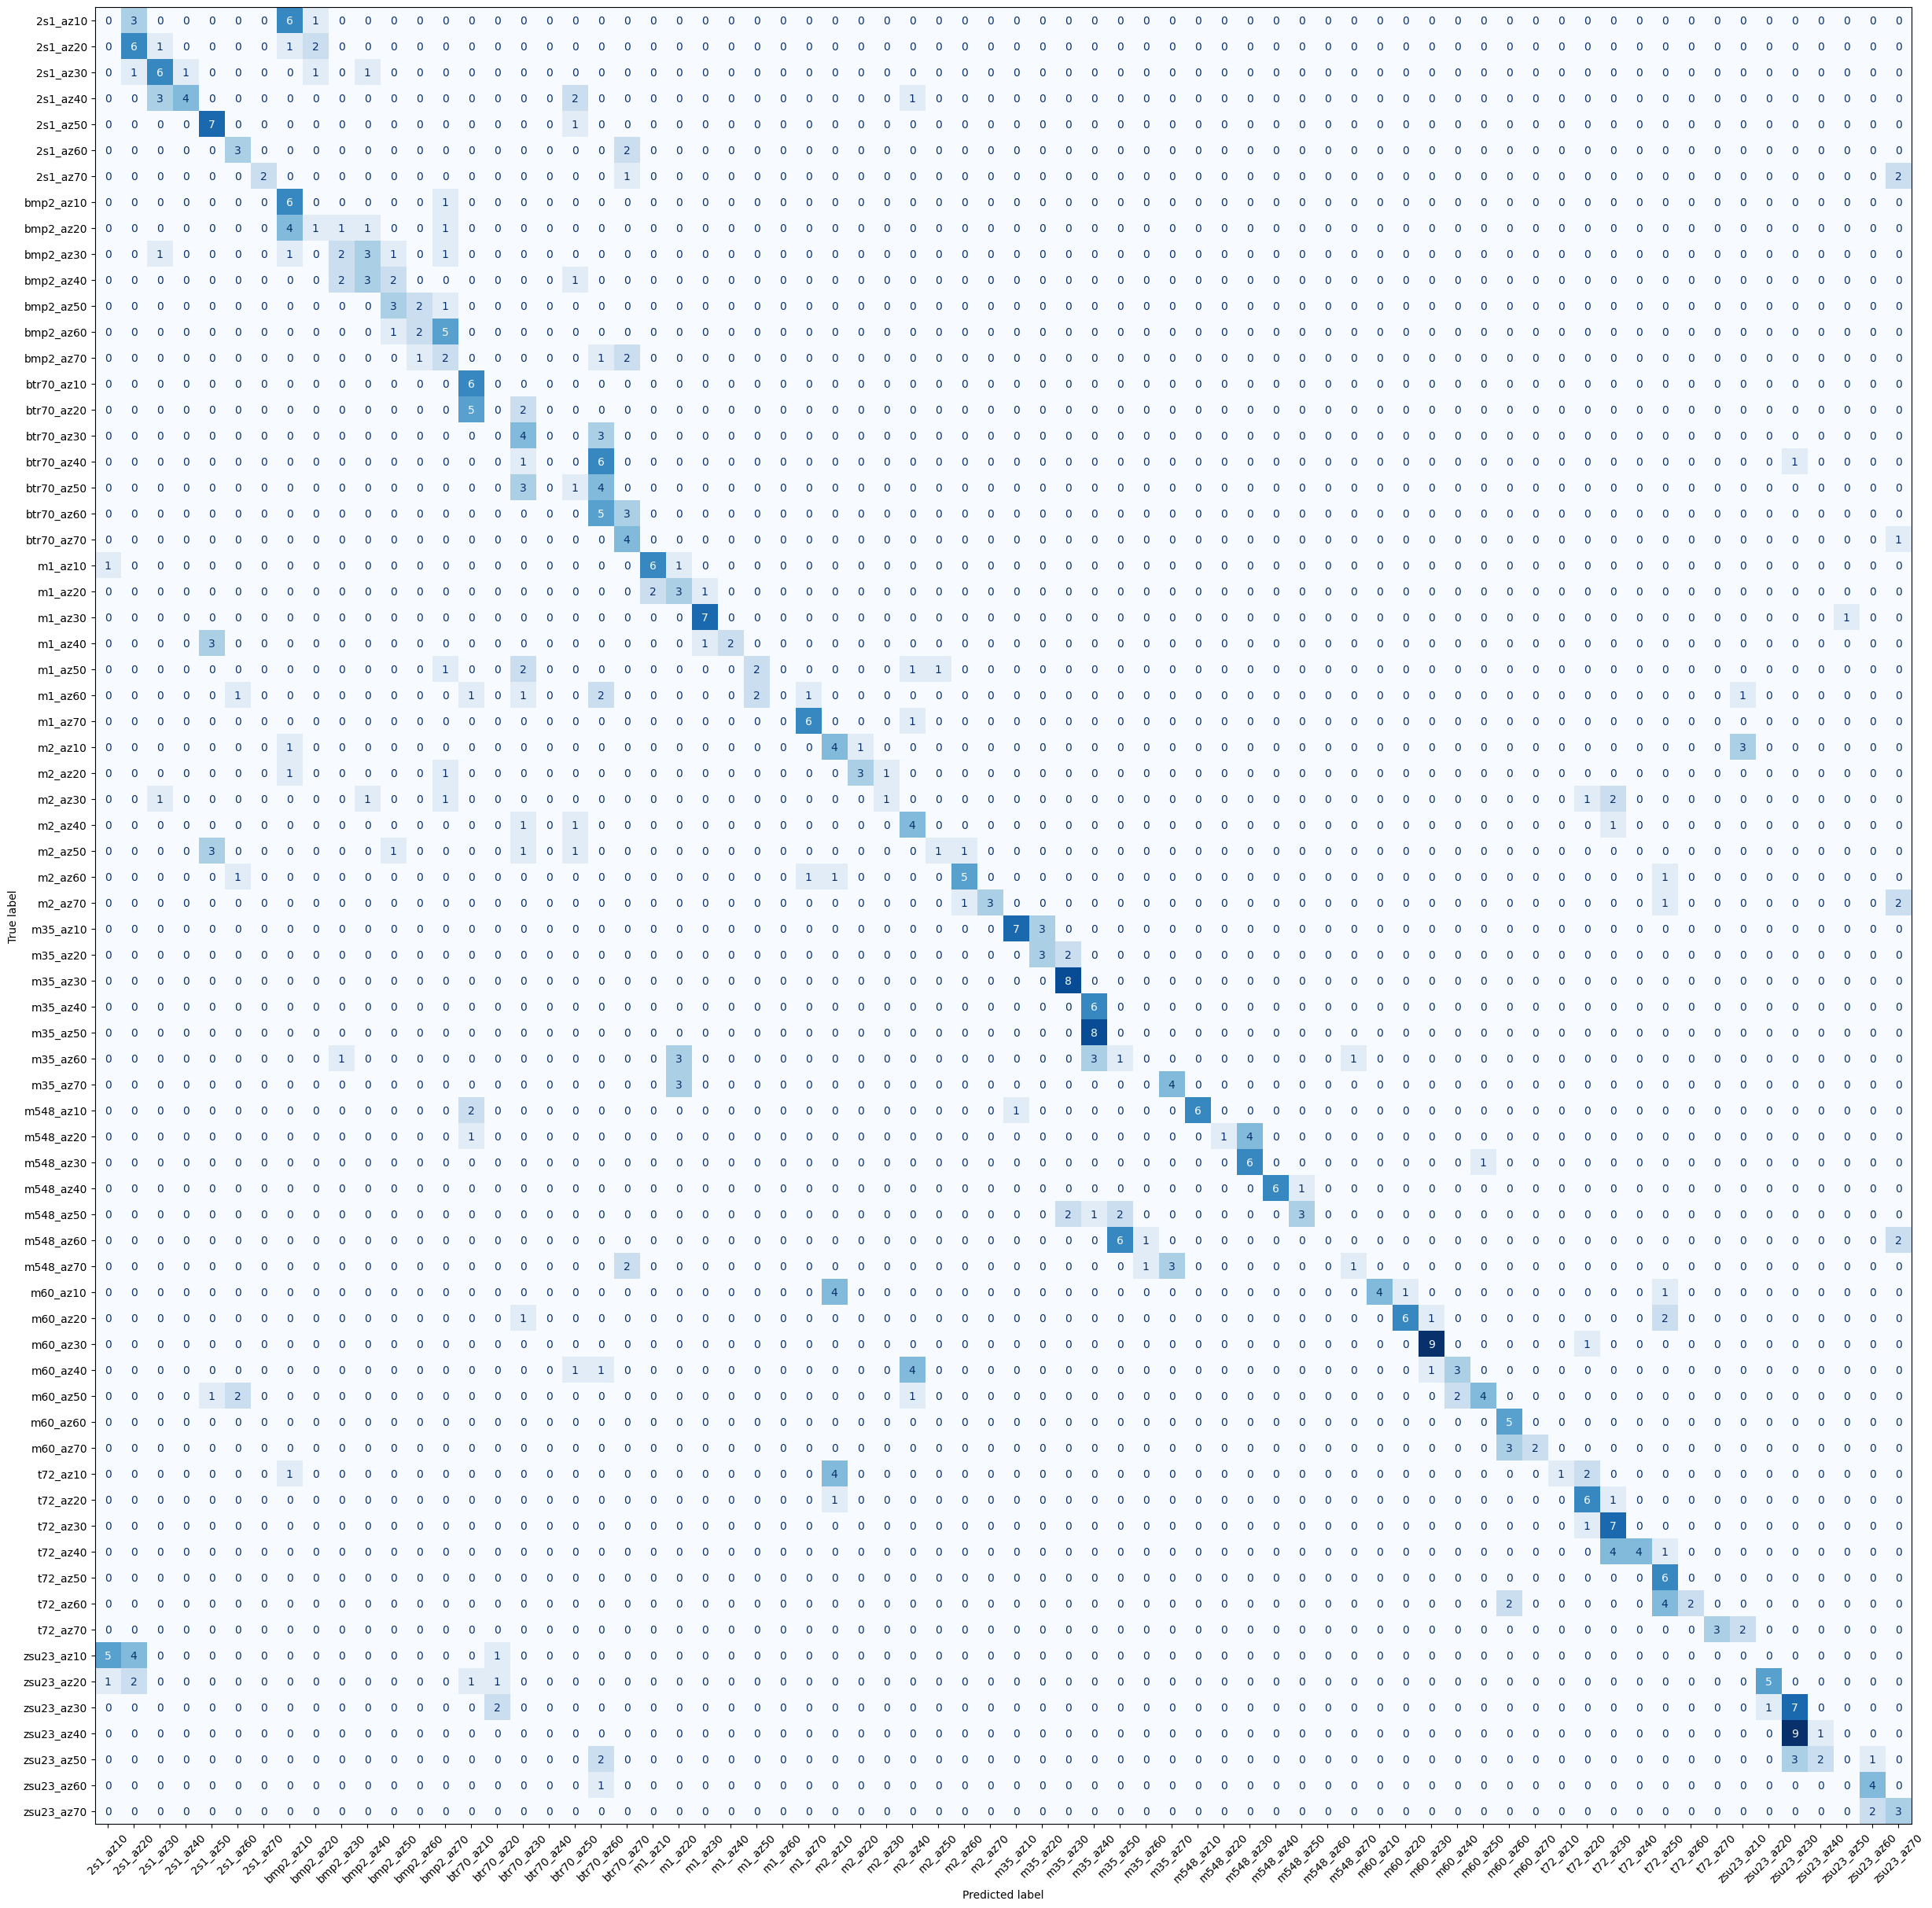

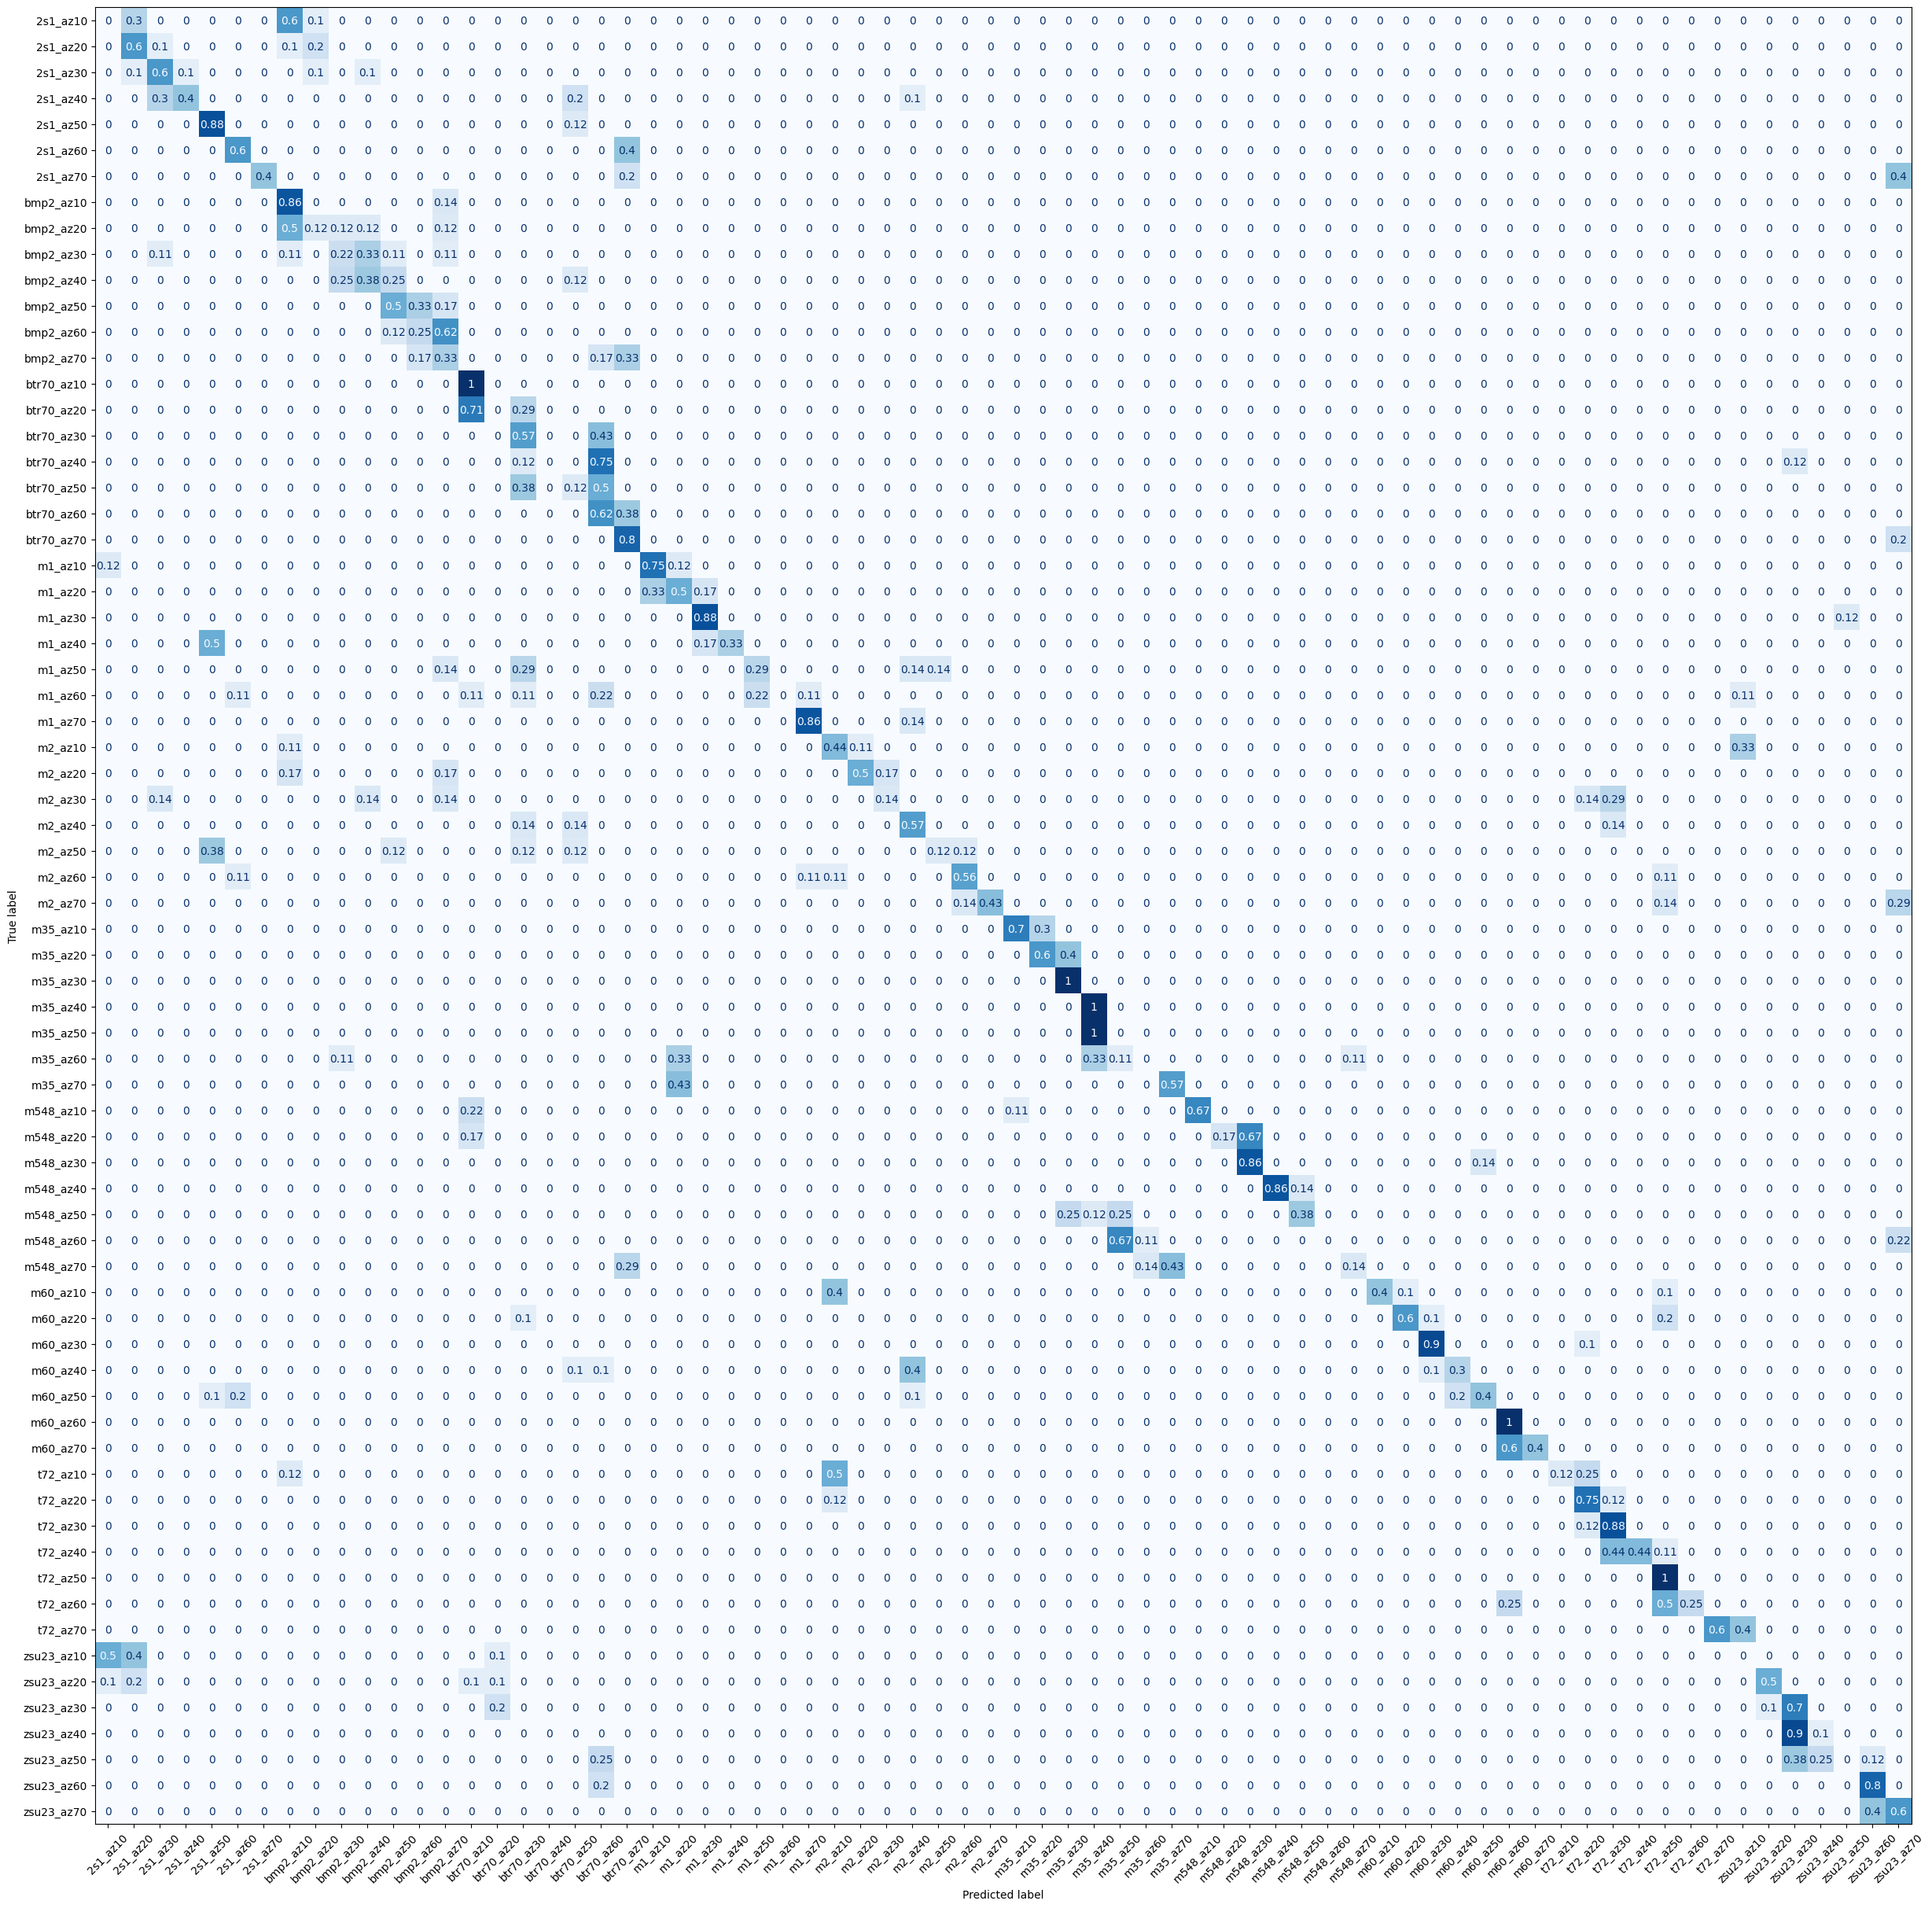

In [13]:
test_dataloader = DataLoader(
    test_ds, batch_size=32, shuffle=False, 
    num_workers=8, pin_memory = True, persistent_workers=True, 
    prefetch_factor=4
                            )

for k in [10**3]:
    print(f"\nEvaluating with k={k} forward passes for MC Dropout...")

    seed_lst = [777]
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    test_acc_lst = []

    for i, seed in enumerate(seed_lst):
        print(f"Evaluating Run {i}: seed {seed}")
        set_seed(seed)
        
        # Reconstruct architecture exactly as trained
        new_model = models.resnet18(weights=None)
        new_model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(new_model.fc.in_features, len(test_ds.classes))
        )
        
        dropout_rate = 0.1
        for layer in [new_model.layer1, new_model.layer2, new_model.layer3, new_model.layer4]:
            for block in layer:
                block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
                def make_forward(b, orig_fwd):
                    def forward(x):
                        out = orig_fwd(x)
                        return b.block_dropout(out)
                    return forward
                block.forward = make_forward(block, block.forward)

        new_model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/wo_aug/rn18_seed{seed}_b16_mc.pth"),
            map_location=device
        ))
        
        new_model = new_model.to(device)
        new_model.eval()
        for m in new_model.modules():
            if isinstance(m, nn.Dropout2d):
                m.train()

        n_test = len(test_ds)
        labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
        preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)

        idx = 0
        with torch.no_grad():
            for inputs, labels in tqdm(test_dataloader, desc="Evaluating", leave = False):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # k forward passes, average probabilities, then classify
                preds_mc = torch.stack([new_model(inputs) for _ in range(k)], dim=0)
                mean_probs = torch.softmax(preds_mc, dim=-1).mean(0)
                _, preds = torch.max(mean_probs, 1)

                batch_size = labels.size(0)
                labels_tensor[idx:idx+batch_size] = labels
                preds_tensor[idx:idx+batch_size] = preds
                idx += batch_size

        _labels_all = labels_tensor.cpu().numpy()
        _preds_all = preds_tensor.cpu().numpy()
    

    # confusion matrix
    cm = confusion_matrix(_labels_all, _preds_all)
    cm_cpu  = cp.asnumpy(cm)

    disp = ConfusionMatrixDisplay(cm_cpu, display_labels = test_ds.classes)
    fig, ax = plt.subplots(figsize=(30, 30))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.tick_params(axis='x', rotation=45)
    plt.show()

    cm_norm = confusion_matrix(_labels_all, _preds_all, normalize = "true")
    cm_norm_cpu  = cp.asnumpy(cm_norm)
    disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = test_ds.classes)
    fig, ax = plt.subplots(figsize=(30, 30))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.tick_params(axis='x', rotation=45)
    plt.show()

In [14]:
test_dataloader = DataLoader(
    test_ds, batch_size=16, shuffle=False, 
    num_workers=8, pin_memory = True, persistent_workers=True, 
    prefetch_factor=4
                            )

for k in [10**3]:
    print(f"\nEvaluating with k={k} forward passes for MC Dropout...")

    seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    test_acc_lst = []

    for i, seed in enumerate(seed_lst):
        print(f"Evaluating Run {i}: seed {seed}")
        set_seed(seed)
        
        # Reconstruct architecture exactly as trained
        new_model = models.resnet18(weights=None)
        new_model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(new_model.fc.in_features, len(test_ds.classes))
        )
        
        dropout_rate = 0.1
        for layer in [new_model.layer1, new_model.layer2, new_model.layer3, new_model.layer4]:
            for block in layer:
                block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
                def make_forward(b, orig_fwd):
                    def forward(x):
                        out = orig_fwd(x)
                        return b.block_dropout(out)
                    return forward
                block.forward = make_forward(block, block.forward)

        new_model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/wo_aug/rn18_seed{seed}_b16_mc.pth"),
            map_location=device
        ))
        
        new_model = new_model.to(device)
        new_model.eval()
        for m in new_model.modules():
            if isinstance(m, nn.Dropout2d):
                m.train()

        n_test = len(test_ds)
        labels_tensor  = torch.zeros(n_test, dtype=torch.long, device=device)
        preds_tensor   = torch.zeros(n_test, dtype=torch.long, device=device)

        idx = 0
        with torch.no_grad():
            for inputs, labels in test_dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # k forward passes, average probabilities, then classify
                preds_mc = torch.stack([new_model(inputs) for _ in range(k)], dim=0)
                mean_probs = torch.softmax(preds_mc, dim=-1).mean(0)
                _, preds = torch.max(mean_probs, 1)

                batch_size = labels.size(0)
                labels_tensor[idx:idx+batch_size] = labels
                preds_tensor[idx:idx+batch_size] = preds
                idx += batch_size

        _labels_tensor = labels_tensor.cpu().numpy()
        _preds_tensor = preds_tensor.cpu().numpy()
        
        _old_class_labels = np.array([new_to_old_classes[_labels_tensor[i]] for i in range(len(_labels_tensor))])
        _old_class_preds = np.array([new_to_old_classes[_preds_tensor[i]] for i in range(len(_preds_tensor))])
        
        test_acc = (_old_class_labels == _old_class_preds).mean()
        print(f"Test Accuracy: {test_acc*100:.4f}")
        test_acc_lst.append(test_acc)

    test_acc_arr = np.array(test_acc_lst)
    print(f"Min: {test_acc_arr.min() * 100:.4f}")
    print(f"Max: {test_acc_arr.max() * 100:.4f}")
    print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")


Evaluating with k=1000 forward passes for MC Dropout...
Evaluating Run 0: seed 10
Test Accuracy: 76.4378
Evaluating Run 1: seed 42
Test Accuracy: 75.8813
Evaluating Run 2: seed 100
Test Accuracy: 73.6549
Evaluating Run 3: seed 123
Test Accuracy: 70.1299
Evaluating Run 4: seed 666
Test Accuracy: 68.2746
Evaluating Run 5: seed 777
Test Accuracy: 71.4286
Evaluating Run 6: seed 849
Test Accuracy: 70.8720
Evaluating Run 7: seed 1000
Test Accuracy: 77.1800
Evaluating Run 8: seed 1111
Test Accuracy: 76.6234
Evaluating Run 9: seed 1234
Test Accuracy: 73.2839
Min: 68.2746
Max: 77.1800
Avg, Std: 73.3766, 2.9560



Evaluating with k=1000 forward passes for MC Dropout...
Evaluating Run 0: seed 777


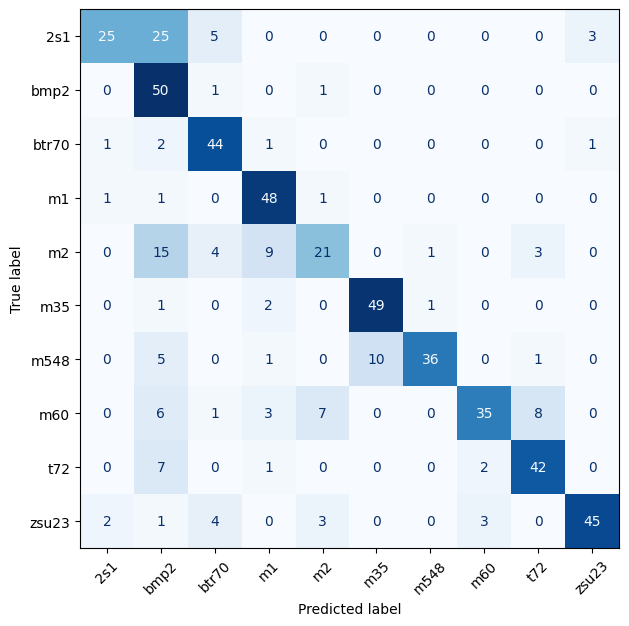

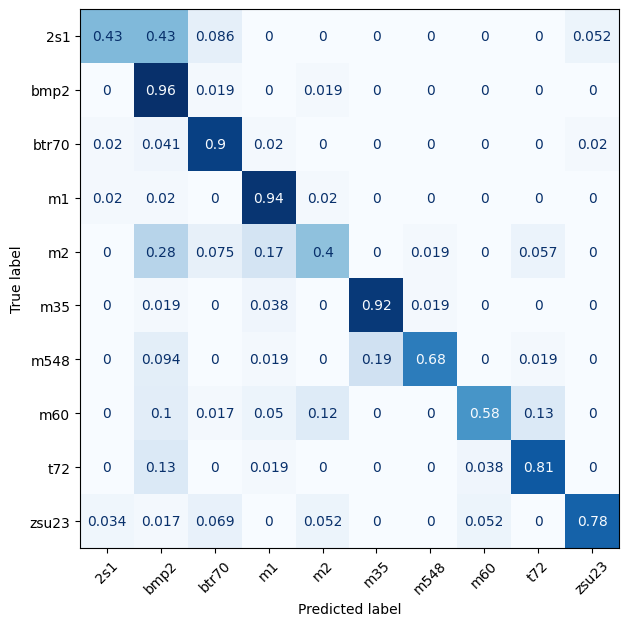

In [ ]:
test_dataloader = DataLoader(
    test_ds, batch_size=32, shuffle=False, 
    num_workers=8, pin_memory = True, persistent_workers=True, 
    prefetch_factor=4
                            )

for k in [10**3]:
    print(f"\nEvaluating with k={k} forward passes for MC Dropout...")

    seed_lst = [777]
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    test_acc_lst = []

    for i, seed in enumerate(seed_lst):
        print(f"Evaluating Run {i}: seed {seed}")
        set_seed(seed)
        
        # Reconstruct architecture exactly as trained
        new_model = models.resnet18(weights=None)
        new_model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(new_model.fc.in_features, len(test_ds.classes))
        )
        
        dropout_rate = 0.1
        for layer in [new_model.layer1, new_model.layer2, new_model.layer3, new_model.layer4]:
            for block in layer:
                block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
                def make_forward(b, orig_fwd):
                    def forward(x):
                        out = orig_fwd(x)
                        return b.block_dropout(out)
                    return forward
                block.forward = make_forward(block, block.forward)

        new_model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/wo_aug/rn18_seed{seed}_b16_mc.pth"),
            map_location=device
        ))
        
        new_model = new_model.to(device)
        new_model.eval()
        for m in new_model.modules():
            if isinstance(m, nn.Dropout2d):
                m.train()

        n_test = len(test_ds)
        labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
        preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)

        idx = 0
        with torch.no_grad():
            for inputs, labels in tqdm(test_dataloader, desc="Evaluating", leave = False):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # k forward passes, average probabilities, then classify
                preds_mc = torch.stack([new_model(inputs) for _ in range(k)], dim=0)
                mean_probs = torch.softmax(preds_mc, dim=-1).mean(0)
                _, preds = torch.max(mean_probs, 1)

                batch_size = labels.size(0)
                labels_tensor[idx:idx+batch_size] = labels
                preds_tensor[idx:idx+batch_size] = preds
                idx += batch_size

        _labels_all = labels_tensor.cpu().numpy()
        _preds_all = preds_tensor.cpu().numpy()
    
        _old_class_labels = np.array([new_to_old_classes[_labels_tensor[i]] for i in range(len(_labels_tensor))])
        _old_class_preds = np.array([new_to_old_classes[_preds_tensor[i]] for i in range(len(_preds_tensor))])

    # confusion matrix
    cm = confusion_matrix(_old_class_labels, _old_class_preds)
    cm_cpu  = cp.asnumpy(cm)

    disp = ConfusionMatrixDisplay(cm_cpu, display_labels = test_ds.dataset.classes)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.tick_params(axis='x', rotation=45)
    plt.show()

    cm_norm = confusion_matrix(_old_class_labels, _old_class_preds, normalize = "true")
    cm_norm_cpu  = cp.asnumpy(cm_norm)
    disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels = test_ds.dataset.classes)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.tick_params(axis='x', rotation=45)
    plt.show()

In [17]:
def make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle, start_lightness=0.3):
    """
    For each vehicle, interpolate from a light tint to the tab10 base colour.
    Returns a flat list of (R,G,B) colours indexed by new_label (bin index).
    """
    tab10 = plt.colormaps["tab10"]
    bin_colors = []
    
    for v in range(n_vehicles):
        base = np.array(tab10(v)[:3])  # RGB of tab10 colour for vehicle v
        white = np.ones(3)
        # linspace from near-white to full colour, n_bins steps
        # start at start_lightness (not pure white) so first bin is still visible
        alphas = np.linspace(start_lightness, 1.0, n_bins_per_vehicle)
        for a in alphas:
            color = (1 - a) * white + a * base
            bin_colors.append(tuple(color))
    
    return bin_colors

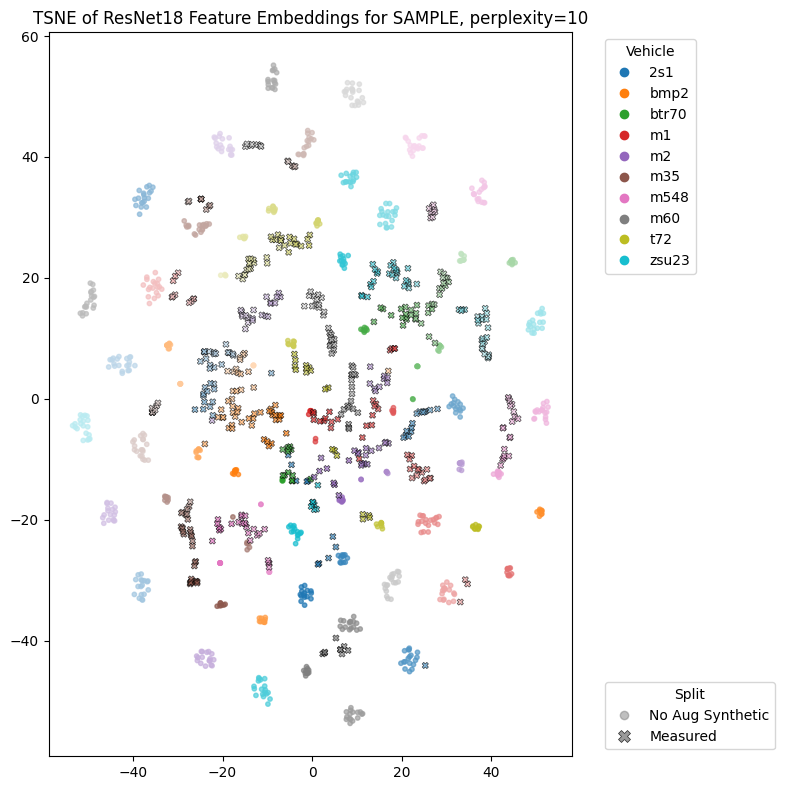

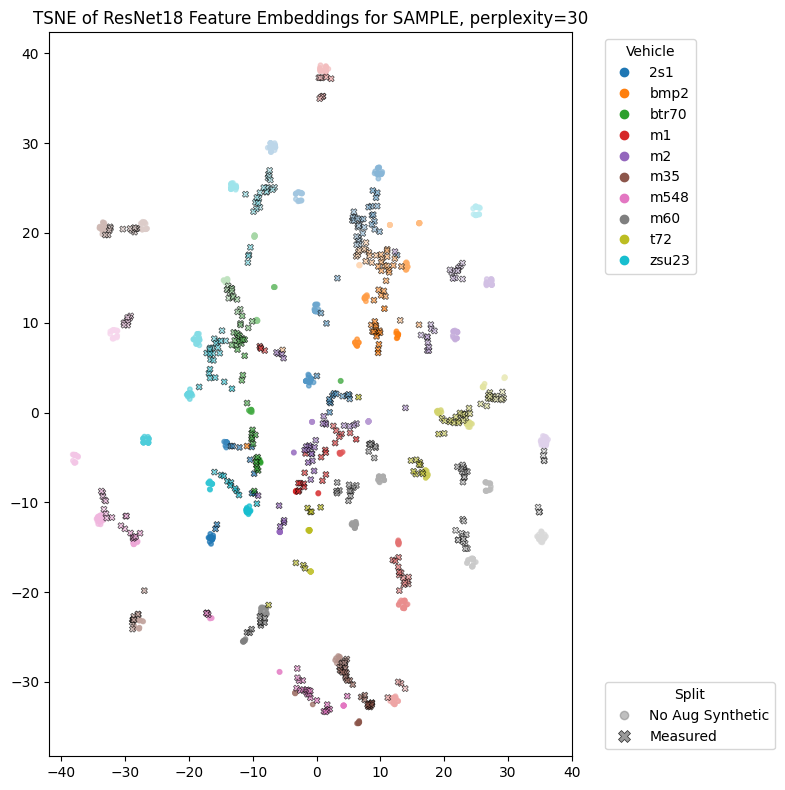

[2026-07-01 01:46:57.704] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


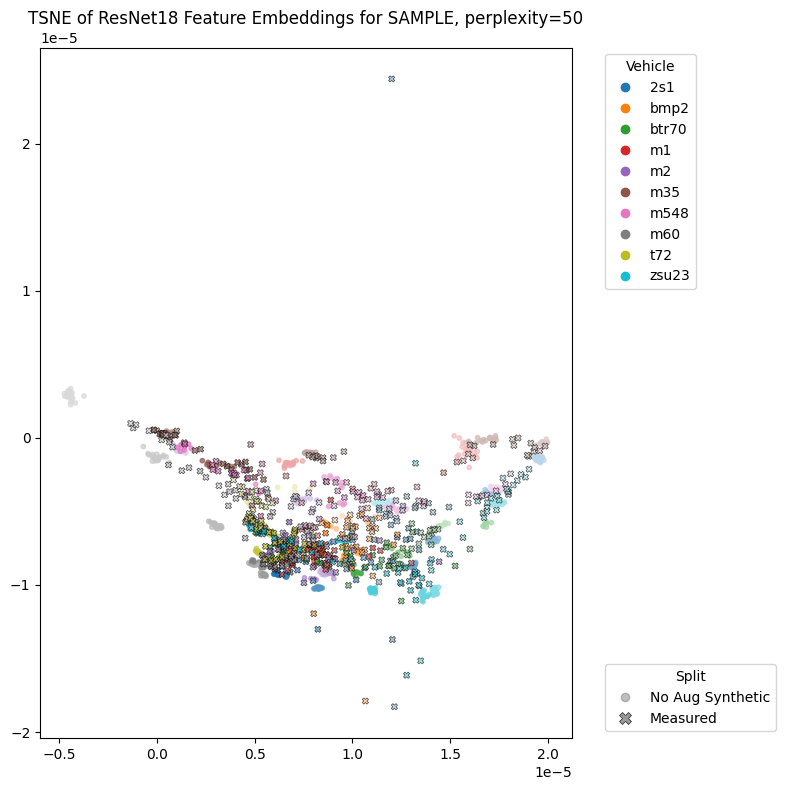

[2026-07-01 01:46:57.855] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...
[2026-07-01 01:46:57.855] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


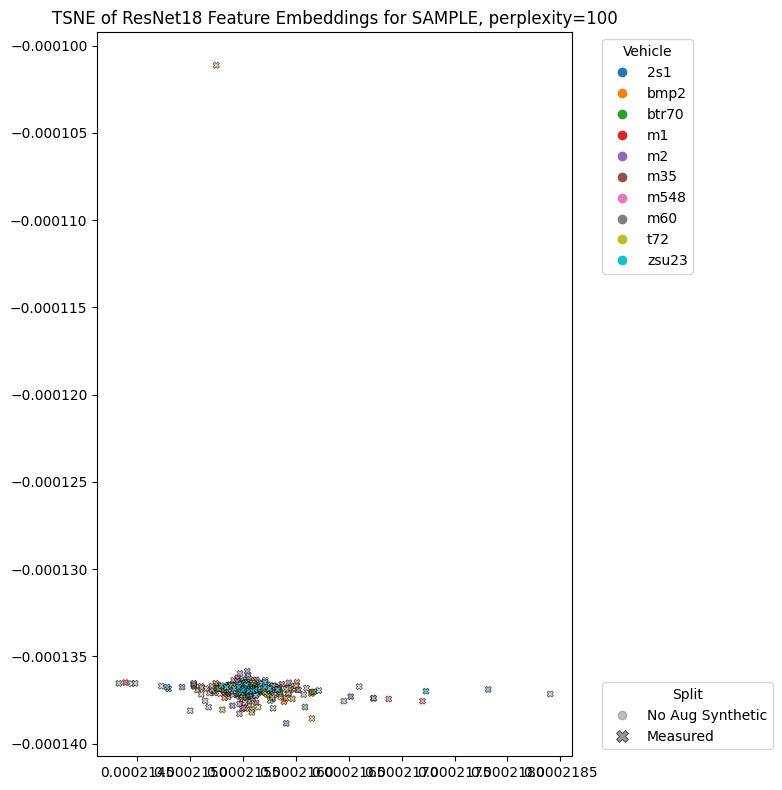

In [19]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
test_plot_ds =  AzimuthBinnedDataset(meas_ds_17, s, new_classes)

no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
s, b, total_bins, new_classes_train, new_to_old_classes_train = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)
train_plot_ds =  AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes_train)

combined_ds = ConcatDataset([train_plot_ds, test_plot_ds])
combined_loader = DataLoader(combined_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
    
set_seed(777)

device = torch.device("cuda:0")
new_model = models.resnet18(weights=None)
new_model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(new_model.fc.in_features, len(test_plot_ds.classes))
)

dropout_rate = 0.1
for layer in [new_model.layer1, new_model.layer2, new_model.layer3, new_model.layer4]:
    for block in layer:
        block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
        def make_forward(b, orig_fwd):
            def forward(x):
                out = orig_fwd(x)
                return b.block_dropout(out)
            return forward
        block.forward = make_forward(block, block.forward)

new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/wo_aug/rn18_seed{seed}_b16_mc.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()
for m in new_model.modules():
    if isinstance(m, nn.Dropout2d):
        m.train()

n_samples = len(combined_ds)
features_tensor = torch.zeros((n_samples, 512), device=device)
labels_tensor = torch.zeros(n_samples, dtype=torch.long, device=device)

hook = new_model.avgpool.register_forward_hook(
    lambda m, inp, out: feats_buffer.append(out.view(out.size(0), -1))
)

idx = 0
feats_buffer = []
with torch.no_grad():
    for inputs, labels in tqdm(combined_loader, desc="Evaluating", leave = False):
        inputs = inputs.to(device)
        labels = labels.to(device)
        feats_buffer.clear()

        # k forward passes, average probabilities, then classify
        preds_mc = torch.stack([new_model(inputs) for _ in range(1000)], dim=0)

        bs = inputs.size(0)
        features_tensor[idx:idx+bs] = torch.stack(feats_buffer, dim=0).mean(0)
        labels_tensor[idx:idx+bs] = labels
        idx += bs


hook.remove()
torch.cuda.synchronize()

_features = features_tensor.cpu().numpy()
_labels = labels_tensor.cpu().numpy()

for num in [10, 30, 50, 100]:

    tsne = TSNE(
        n_components=2,
        perplexity=num,
        learning_rate_method="adaptive",
        metric = "cosine"
    )

    features_2d = tsne.fit_transform(_features)

    n_vehicles = len(train_plot_ds.dataset.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(_labels[:len(train_plot_ds)], bin_colors)
    test_colors  = labels_to_colors(_labels[len(train_plot_ds):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d[:len(train_plot_ds), 0],
        features_2d[:len(train_plot_ds), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d[len(train_plot_ds):, 0],
        features_2d[len(train_plot_ds):, 1],
        c=test_colors,
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    tab10 = plt.colormaps["tab10"]
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=train_plot_ds.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"TSNE of ResNet18 Feature Embeddings for SAMPLE, perplexity={num}")
    plt.tight_layout()
    plt.show()

[2026-07-01 01:52:04.635] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


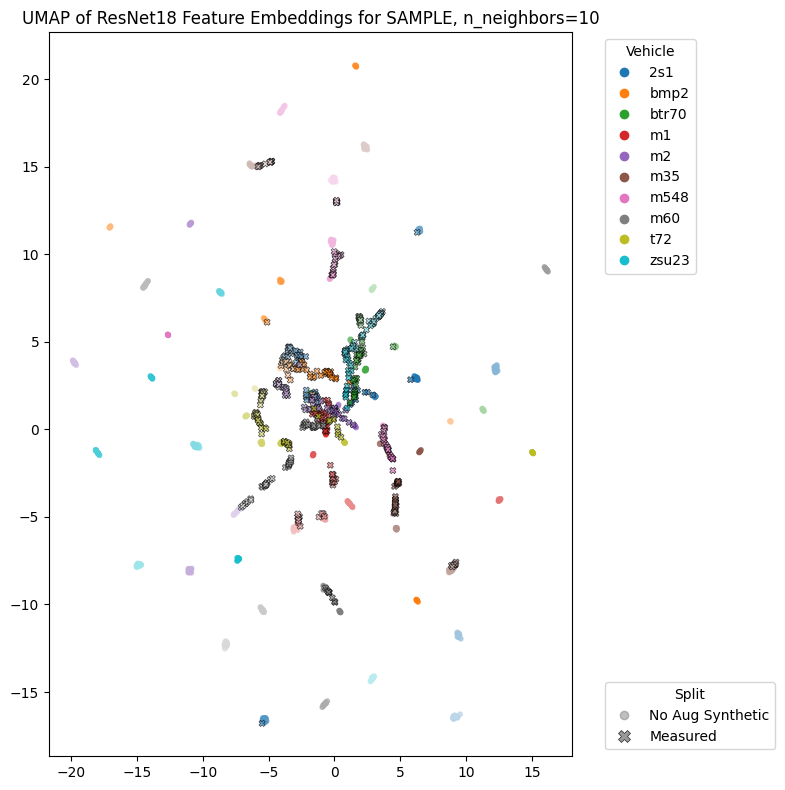

[2026-07-01 01:52:05.273] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


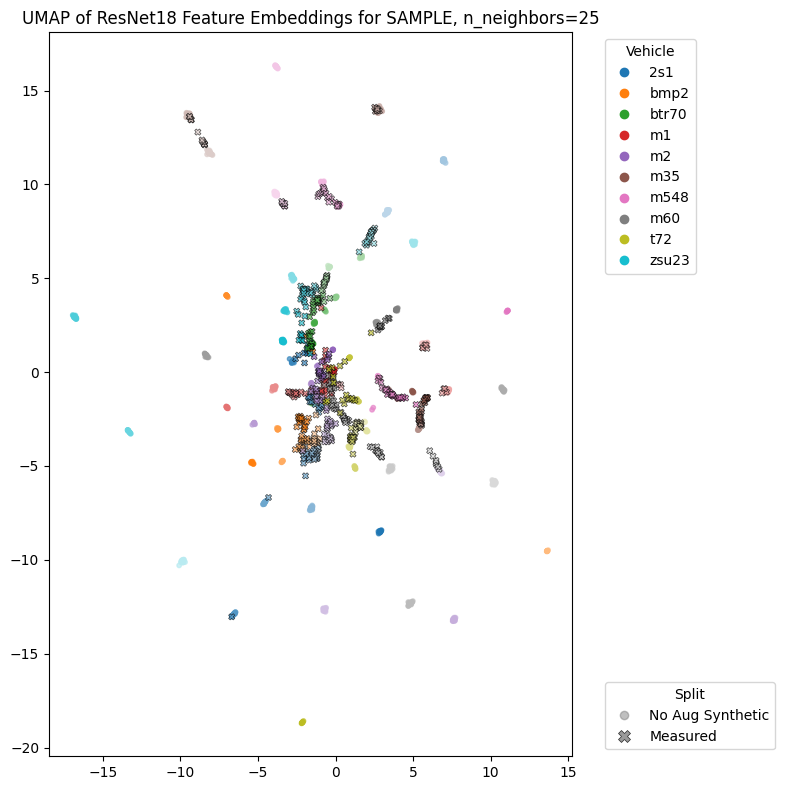

[2026-07-01 01:52:05.658] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


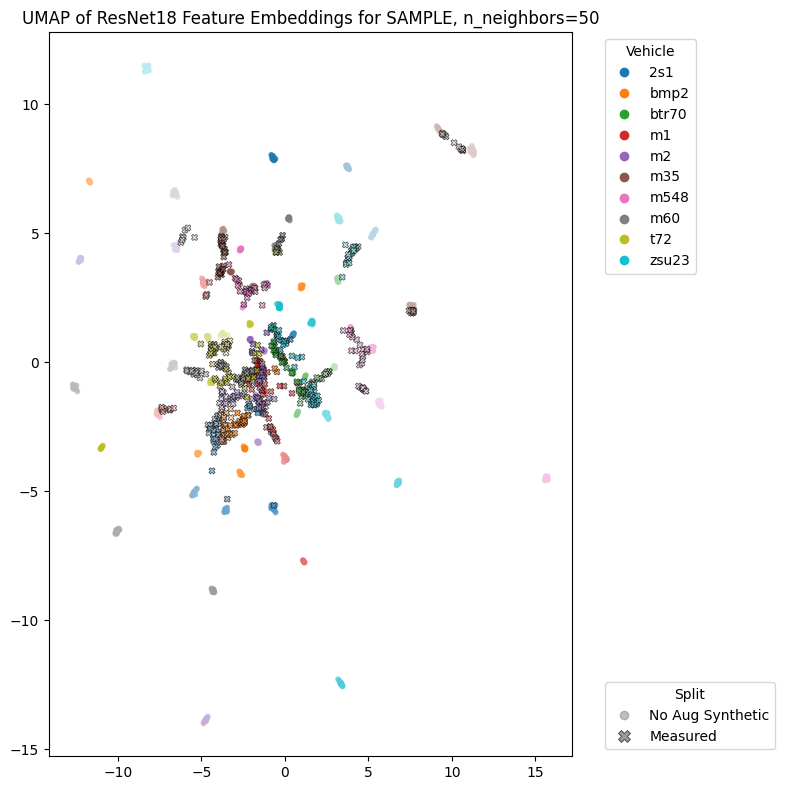

[2026-07-01 01:52:05.840] [CUML] [info] Building knn graph using brute force (configured from build_algo='auto')


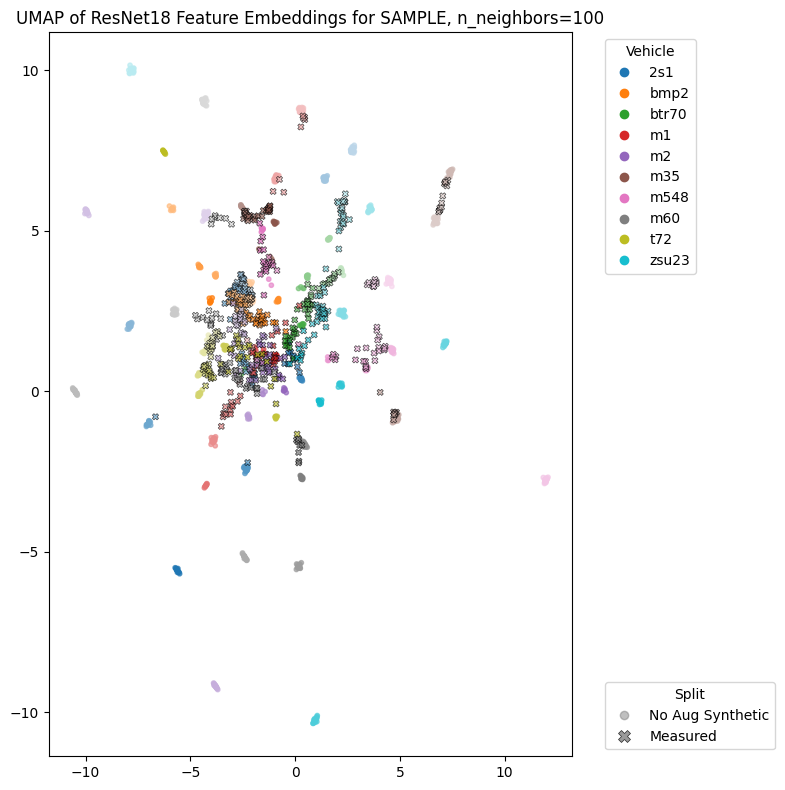

In [21]:
meas_ds_17 = filter_by_elev(meas_ds, {17})
s, b, total_bins, new_classes, new_to_old_classes = build_azimuth_bin_map(meas_ds_17, bin_width=10)
test_plot_ds =  AzimuthBinnedDataset(meas_ds_17, s, new_classes)

no_aug_synth_ds_14_15_16 = filter_by_elev(no_aug_synth_ds, {14, 15, 16})
s, b, total_bins, new_classes_train, new_to_old_classes_train = build_azimuth_bin_map(no_aug_synth_ds_14_15_16, bin_width=10)
train_plot_ds =  AzimuthBinnedDataset(no_aug_synth_ds_14_15_16, s, new_classes_train)

combined_ds = ConcatDataset([train_plot_ds, test_plot_ds])
combined_loader = DataLoader(combined_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
    
set_seed(777)

device = torch.device("cuda:0")
new_model = models.resnet18(weights=None)
new_model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(new_model.fc.in_features, len(test_plot_ds.classes))
)

dropout_rate = 0.1
for layer in [new_model.layer1, new_model.layer2, new_model.layer3, new_model.layer4]:
    for block in layer:
        block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
        def make_forward(b, orig_fwd):
            def forward(x):
                out = orig_fwd(x)
                return b.block_dropout(out)
            return forward
        block.forward = make_forward(block, block.forward)

new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/wo_aug/rn18_seed{seed}_b16_mc.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()
for m in new_model.modules():
    if isinstance(m, nn.Dropout2d):
        m.train()

n_samples = len(combined_ds)
features_tensor = torch.zeros((n_samples, 512), device=device)
labels_tensor = torch.zeros(n_samples, dtype=torch.long, device=device)

hook = new_model.avgpool.register_forward_hook(
    lambda m, inp, out: feats_buffer.append(out.view(out.size(0), -1))
)

idx = 0
feats_buffer = []
with torch.no_grad():
    for inputs, labels in tqdm(combined_loader, desc="Evaluating", leave = False):
        inputs = inputs.to(device)
        labels = labels.to(device)
        feats_buffer.clear()

        # k forward passes, average probabilities, then classify
        preds_mc = torch.stack([new_model(inputs) for _ in range(1000)], dim=0)

        bs = inputs.size(0)
        features_tensor[idx:idx+bs] = torch.stack(feats_buffer, dim=0).mean(0)
        labels_tensor[idx:idx+bs] = labels
        idx += bs


hook.remove()
torch.cuda.synchronize()

_features = features_tensor.cpu().numpy()
_labels = labels_tensor.cpu().numpy()

for num in [10, 25, 50, 100]:

    reducer = UMAP(
        n_neighbors=num,
        min_dist=0.25,
        n_components=2,
        metric = "cosine"
    )

    features_2d_umap = reducer.fit_transform(_features)

    n_vehicles = len(train_plot_ds.dataset.classes)
    n_bins_per_vehicle = total_bins // n_vehicles 

    bin_colors = make_vehicle_bin_colors(n_vehicles, n_bins_per_vehicle)

    def labels_to_colors(label_array, bin_colors):
        return [bin_colors[l] for l in label_array]

    train_colors = labels_to_colors(_labels[:len(train_plot_ds)], bin_colors)
    test_colors  = labels_to_colors(_labels[len(train_plot_ds):], bin_colors)

    fig = plt.figure(figsize=(8, 8))
    scatter = plt.scatter(
        features_2d_umap[:len(train_plot_ds), 0],
        features_2d_umap[:len(train_plot_ds), 1],
        c=train_colors,
        s=10,
        alpha=0.7,
        marker = "o"
    )

    plt.scatter(
        features_2d_umap[len(train_plot_ds):, 0],
        features_2d_umap[len(train_plot_ds):, 1],
        c=test_colors,
        s=20,
        alpha=0.7,
        linewidths=0.5,
        marker = "X",
        edgecolors="k"
    )

    tab10 = plt.colormaps["tab10"]
    vehicle_handles = [
        Line2D([0], [0], marker="o", color=tab10(v), linestyle="None",
            markersize=6, label=train_plot_ds.dataset.classes[v])
        for v in range(n_vehicles)
    ]
    class_legend = plt.legend(handles=vehicle_handles, title="Vehicle",
                            bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.add_artist(class_legend)

    marker_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synthetic"),
        Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
    ]
    plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

    plt.title(f"UMAP of ResNet18 Feature Embeddings for SAMPLE, n_neighbors={num}")
    plt.tight_layout()
    plt.show()

In [13]:
def _get_features_and_preds_from_mc_model(model, dataset, device, seed, k=1000):
    model = model.to(device)
    model.eval()
    for m in model.modules():
        if isinstance(m, nn.Dropout2d):
            m.train()

    n_samples = len(dataset)
    features_tensor = torch.zeros((n_samples, 512), device=device)
    labels_tensor   = torch.zeros(n_samples, dtype=torch.long, device=device)
    preds_tensor    = torch.zeros(n_samples, dtype=torch.long, device=device)

    hook = model.avgpool.register_forward_hook(
        lambda m, inp, out: feats_buffer.append(out.view(out.size(0), -1))
    )

    idx = 0
    feats_buffer = []
    with torch.no_grad():
        for inputs, targets in tqdm(
            DataLoader(dataset, batch_size=32, shuffle=False, num_workers=8,
                    pin_memory=True, persistent_workers=True,
                    worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
                    leave=False):

            inputs  = inputs.to(device)
            targets = targets.to(device)
            feats_buffer.clear()

            preds_mc = torch.stack([model(inputs) for _ in range(k)], dim=0)

            bs = inputs.size(0)
            features_tensor[idx:idx+bs] = torch.stack(feats_buffer, dim=0).mean(0)
            labels_tensor[idx:idx+bs] = targets
            preds_tensor[idx:idx+bs] = torch.softmax(preds_mc, dim=-1).mean(0).argmax(1)
            idx += bs

    hook.remove()
    torch.cuda.synchronize()

    _features = features_tensor.cpu().numpy()
    _labels = labels_tensor.cpu().numpy()
    _preds = preds_tensor.cpu().numpy()

    return cp.asarray(_features), cp.asarray(_labels), cp.asarray(_preds)

In [14]:
seed_lst = [777]
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: seed {seed}")
    set_seed(seed)
    
    # Reconstruct architecture exactly as trained
    model = models.resnet18(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(model.fc.in_features, len(test_ds.classes))
    )
    
    dropout_rate = 0.1
    for layer in [model.layer1, model.layer2, model.layer3, model.layer4]:
        for block in layer:
            block.add_module('block_dropout', nn.Dropout2d(p=dropout_rate))
            def make_forward(b, orig_fwd):
                def forward(x):
                    out = orig_fwd(x)
                    return b.block_dropout(out)
                return forward
            block.forward = make_forward(block, block.forward)

    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/bins_10deg/wo_aug/rn18_seed{seed}_b16_mc.pth"),
        map_location=device
    ))

    synth_features, synth_labels, _ = _get_features_and_preds_from_mc_model(model, new_no_aug_synth_ds_14_15_16, device, seed, k = 1000)
    meas_features, meas_labels, meas_preds = _get_features_and_preds_from_mc_model(model, new_meas_ds_17, device, seed, k = 1000)

    old_synth_labels = cp.array([new_to_old_classes[synth_labels[i].item()] for i in range(len(synth_labels))])
    old_meas_labels = cp.array([new_to_old_classes[meas_labels[i].item()] for i in range(len(meas_labels))])
    old_meas_preds = cp.array([new_to_old_classes[meas_preds[i].item()] for i in range(len(meas_preds))])

Evaluating Run 0: seed 777


In [15]:
cosine_d_true_class, cosine_n_true_class = k_nearest_neighbors_by_true_class(
    meas_features, old_meas_labels, synth_features, old_synth_labels, metric = "cosine"
)

Class       q= 1  q= 3  q= 5
----------------------------
2s1         0.703  0.892  0.973  (n=37)
bmp2        0.447  0.574  0.745  (n=47)
btr70       0.468  0.617  0.681  (n=47)
m1          0.686  0.943  1.000  (n=35)
m2          0.654  0.962  0.962  (n=26)
m35         0.511  0.711  0.778  (n=45)
m548        0.714  0.857  0.964  (n=28)
m60         0.732  0.878  0.951  (n=41)
t72         0.643  0.810  0.929  (n=42)
zsu23       0.432  0.676  0.757  (n=37)
----------------------------
Overall     0.587  0.774  0.860  (n=385)
Class       q= 1  q= 3  q= 5
----------------------------
2s1         26.000  33.000  36.000  (n=37)
bmp2        21.000  27.000  35.000  (n=47)
btr70       22.000  29.000  32.000  (n=47)
m1          24.000  33.000  35.000  (n=35)
m2          17.000  25.000  25.000  (n=26)
m35         23.000  32.000  35.000  (n=45)
m548        20.000  24.000  27.000  (n=28)
m60         30.000  36.000  39.000  (n=41)
t72         27.000  34.000  39.000  (n=42)
zsu23       16.000  25.000 

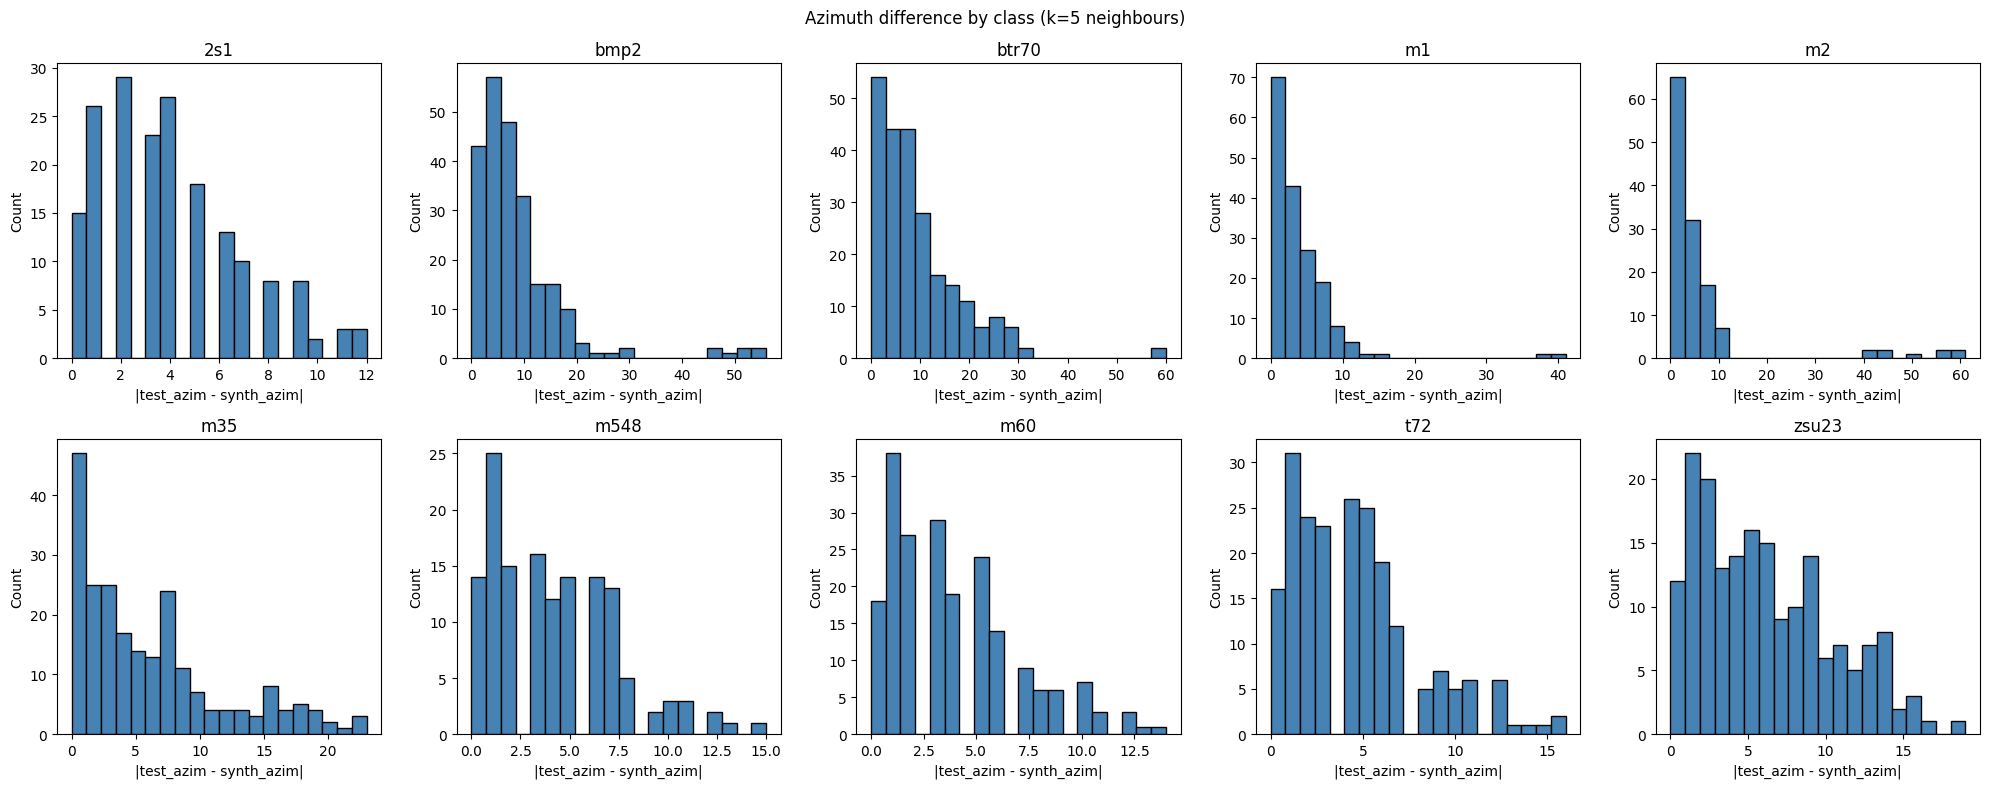

In [16]:
results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds.dataset, old_meas_labels, old_meas_preds,
    train_ds.dataset, cosine_n_true_class,
    q_values=[1, 3, 5],
    k = 5
)

results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds.dataset, old_meas_labels, old_meas_preds,
    train_ds.dataset, cosine_n_true_class,
    q_values=[1, 3, 5], k = 5, normalise = False
)

results, azim_diffs = cp.asnumpy(results), cp.asnumpy(azim_diffs)

correct_mask    = cp.asnumpy(old_meas_preds) == cp.asnumpy(old_meas_labels)
correct_classes = cp.asnumpy(old_meas_labels)[np.where(correct_mask)[0]]
plot_azim_diffs_by_class(test_ds.dataset, azim_diffs, correct_classes)